# Q4: Simple CNN for Classification + BBox Regression

This notebook is intentionally minimal and avoids SE blocks or heavy tricks. It loads Oxford Pets, applies a basic resize + normalize transform, trains a small CNN, and visualizes one prediction.

In [383]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from datasets import load_dataset
import pytorch_lightning as pl
import torchmetrics
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(67)
np.random.seed(67)
random.seed(67)

In [384]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [385]:
# Dataset + simple transform (with light augmentation for train)
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

_color_jitter = transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)

def _scale_bbox(box, orig_w, orig_h, new_w, new_h):
    x1, y1, x2, y2 = box
    sx = new_w / orig_w
    sy = new_h / orig_h
    return [x1 * sx, y1 * sy, x2 * sx, y2 * sy]

def _transform_one(img, bbox, train=False):
    orig_w, orig_h = img.size
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    bbox = _scale_bbox(bbox, orig_w, orig_h, IMG_SIZE, IMG_SIZE)

    if train and random.random() < 0.5:
        img = TF.hflip(img)
        x1, y1, x2, y2 = bbox
        bbox = [IMG_SIZE - x2, y1, IMG_SIZE - x1, y2]

    if train and random.random() < 0.3:
        img = _color_jitter(img)

    img = TF.to_tensor(img)
    img = TF.normalize(img, mean=MEAN, std=STD)
    bbox = torch.tensor([b / IMG_SIZE for b in bbox], dtype=torch.float32)
    return img, bbox

def transform_example(example, train=False):
    imgs = example["img"]
    bboxes = example["bbox"]
    if isinstance(imgs, list):
        new_imgs = []
        new_boxes = []
        for i, img in enumerate(imgs):
            img_t, box_t = _transform_one(img, bboxes[i], train=train)
            new_imgs.append(img_t)
            new_boxes.append(box_t)
        example["img"] = new_imgs
        example["bbox"] = new_boxes
    else:
        img_t, box_t = _transform_one(imgs, bboxes, train=train)
        example["img"] = img_t
        example["bbox"] = box_t
    return example

def transform_train(example):
    return transform_example(example, train=True)

def transform_eval(example):
    return transform_example(example, train=False)

_ds = load_dataset("cvdl/oxford-pets")

# Keep only needed columns to avoid collate issues
keep_cols = {"img", "bbox", "category"}
for split_name in ["train", "valid", "test"]:
    cols = list(_ds[split_name].column_names)
    drop_cols = [c for c in cols if c not in keep_cols]
    if drop_cols:
        _ds[split_name] = _ds[split_name].remove_columns(drop_cols)

train_ds = _ds["train"].with_transform(transform_train)
valid_ds = _ds["valid"].with_transform(transform_eval)
test_ds = _ds["test"].with_transform(transform_eval)

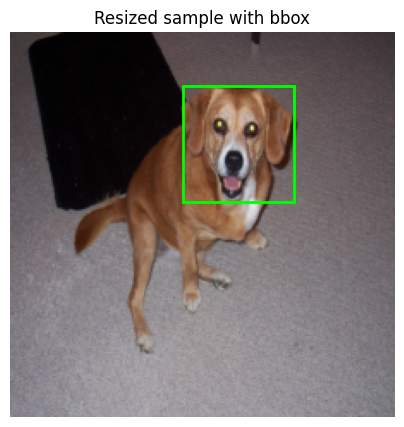

In [386]:
# Quick check: visualize a random resized sample with bbox
def _denorm(img):
    img = img.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

idx = random.randrange(len(train_ds))
sample = train_ds[idx]
img = sample["img"]
bbox = (sample["bbox"] * IMG_SIZE).tolist()

def _to_xyxy(b):
    return [min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3])]

x1, y1, x2, y2 = _to_xyxy(bbox)
img_vis = _denorm(img).permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_vis)
ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2, edgecolor="lime", facecolor="none"))
ax.set_title("Resized sample with bbox")
ax.axis("off")
plt.show()

In [387]:
# DataLoaders
BATCH_SIZE = 64
NUM_WORKERS = 0

def make_loaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, valid_loader, test_loader

train_loader, valid_loader, test_loader = make_loaders()
print("Data loaders ready")

Data loaders ready


In [388]:
class SimpleCNN(pl.LightningModule):
    def __init__(self, num_classes=37, lr=1e-3, bbox_loss_weight=3.0, bbox_lr_mult=2.0):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.bbox_loss_weight = bbox_loss_weight
        self.bbox_lr_mult = bbox_lr_mult

        # Simple but stronger: more channels + extra block
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        
        # Unified pooling for better feature sharing
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.dropout = nn.Dropout(0.4)
        self.class_head = nn.Sequential(
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        # Improved bbox head with less aggressive compression
        self.bbox_head = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        feats = self.features(x)
        
        # Shared pooling
        pooled = self.pool(feats).view(x.size(0), -1)
        
        class_feats = self.dropout(pooled)
        class_logits = self.class_head(class_feats)
        
        # Return raw bbox logits (no sigmoid here)
        bbox = self.bbox_head(pooled)
        return class_logits, bbox
    
    def _unpack(self, batch):
        if isinstance(batch, dict):
            images = batch["img"]
            labels = batch["category"]
            bboxes = batch["bbox"]
        else:
            images, labels, bboxes = batch
        if not torch.is_tensor(bboxes):
            bboxes = torch.tensor(bboxes, device=images.device, dtype=torch.float32)
        bboxes = bboxes.float()
        labels = labels.long()
        return images, labels, bboxes

    def _shared_step(self, batch):
        images, labels, bboxes = self._unpack(batch)
        logits, pred_bboxes = self(images)
        loss_cls = F.cross_entropy(logits, labels)
        # Apply sigmoid here for loss computation
        pred_bboxes_norm = torch.sigmoid(pred_bboxes)
        loss_bbox = F.smooth_l1_loss(pred_bboxes_norm, bboxes)
        loss = loss_cls + self.bbox_loss_weight * loss_bbox
        preds = torch.argmax(logits, dim=1)
        return loss, loss_cls, loss_bbox, preds, labels

    def training_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        self.log("train_cls_loss", loss_cls)
        self.log("train_bbox_loss", loss_bbox)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels = self._shared_step(batch)
        self.val_acc(preds, labels)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)
        self.log("val_cls_loss", loss_cls)
        self.log("val_bbox_loss", loss_bbox)

    def test_step(self, batch, batch_idx):
        loss, loss_cls, loss_bbox, preds, labels = self._shared_step(batch)
        self.test_acc(preds, labels)
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_acc, prog_bar=True)
        self.log("test_cls_loss", loss_cls)
        self.log("test_bbox_loss", loss_bbox)

    def configure_optimizers(self):
        return torch.optim.Adam(
            [
                {"params": self.features.parameters(), "lr": self.lr},
                {"params": self.class_head.parameters(), "lr": self.lr},
                {"params": self.bbox_head.parameters(), "lr": self.lr * self.bbox_lr_mult},
            ]
        )

print("SimpleCNN ready")

SimpleCNN ready


In [398]:
# Train (keep epochs small for a quick run)
model = SimpleCNN(num_classes=37, lr=1e-3, bbox_loss_weight=5.0, bbox_lr_mult=2)
trainer = pl.Trainer(max_epochs=50, accelerator=device, log_every_n_steps=10)
trainer.fit(model, train_loader, valid_loader)
trainer.test(model, test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | features   | Sequential         | 1.2 M  | train | 0    
1 | pool       | AdaptiveAvgPool2d  | 0      | train | 0    
2 | dropout    | Dropout            | 0      | train | 0    
3 | class_head | Sequential         | 1.1 M  | train | 0    
4 | bbox_head  | Sequential         | 2.2 M  | train | 0    
5 | train_acc  | MulticlassAccuracy | 0      | train | 0    
6 | val_acc    | MulticlassAccuracy | 0      | train | 0    
7 | test_acc   | MulticlassAccuracy | 0      | train | 0    
--------------------------------------------------------

Epoch 49: 100%|██████████| 41/41 [00:21<00:00,  1.94it/s, v_num=57, train_loss=1.570, train_acc=0.429, val_loss=2.490, val_acc=0.321] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 41/41 [00:21<00:00,  1.92it/s, v_num=57, train_loss=1.570, train_acc=0.429, val_loss=2.490, val_acc=0.321]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  3.22it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.3002481460571289
     test_bbox_loss        0.0072468663565814495
      test_cls_loss          2.705336809158325
        test_loss           2.7415711879730225
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.7415711879730225,
  'test_acc': 0.3002481460571289,
  'test_cls_loss': 2.705336809158325,
  'test_bbox_loss': 0.0072468663565814495}]

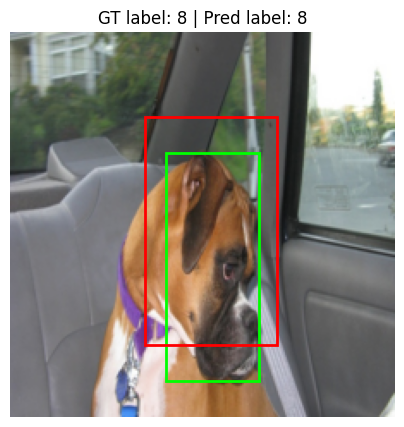

[77.8082046508789, 49.00263977050781, 154.79995727539062, 181.4650115966797]


In [428]:
# Visualize one prediction
def denormalize(img):
    img = img.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

model = model.to(device)
model.eval()
idx = random.randrange(len(test_ds))
sample = test_ds[idx]
img = sample["img"]
gt_bbox = (sample["bbox"] * IMG_SIZE).tolist()
gt_label = int(sample["category"])

with torch.no_grad():
    logits, pred_bbox = model(img.unsqueeze(0).to(device))
    pred_label = int(torch.argmax(logits, dim=1).item())
    # Apply sigmoid for visualization since forward returns raw logits now
    pred_bbox = (torch.sigmoid(pred_bbox).squeeze(0).cpu() * IMG_SIZE).tolist()

def _to_xyxy(b):
    return [min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3])]

gt = _to_xyxy(gt_bbox)
pr = _to_xyxy(pred_bbox)

img_vis = denormalize(img).permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_vis)
ax.add_patch(patches.Rectangle((gt[0], gt[1]), gt[2] - gt[0], gt[3] - gt[1],
                               linewidth=2, edgecolor="lime", facecolor="none"))
ax.add_patch(patches.Rectangle((pr[0], pr[1]), pr[2] - pr[0], pr[3] - pr[1],
                               linewidth=2, edgecolor="red", facecolor="none"))
ax.set_title(f"GT label: {gt_label} | Pred label: {pred_label}")
ax.axis("off")
plt.show()
print(pr)